In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
upload = files.upload()

Saving 2015.csv to 2015.csv
Saving 2016.csv to 2016.csv
Saving 2017.csv to 2017.csv
Saving 2018.csv to 2018.csv
Saving 2019.csv to 2019.csv


In [3]:
df_2015=pd.read_csv('2015.csv')
df_2016=pd.read_csv('2016.csv')
df_2017=pd.read_csv('2017.csv')
df_2018=pd.read_csv('2018.csv')
df_2019=pd.read_csv('2019.csv')

In [4]:
df_2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [5]:
df_2016.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [6]:
df_2017.head()
df_2017.shape

(155, 12)

In [7]:
files = ['2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']

dfs=[]
for file in files:
    df=pd.read_csv(file)
    df.columns=(
        df.columns.str.strip()
        .str.lower()
        .str.replace(' ','_')
    )
    # add year
    df['year'] = int(file[:4])

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
print(combined_df.columns)


Index(['country', 'region', 'happiness_rank', 'happiness_score',
       'standard_error', 'economy_(gdp_per_capita)', 'family',
       'health_(life_expectancy)', 'freedom', 'trust_(government_corruption)',
       'generosity', 'dystopia_residual', 'year', 'lower_confidence_interval',
       'upper_confidence_interval', 'happiness.rank', 'happiness.score',
       'whisker.high', 'whisker.low', 'economy..gdp.per.capita.',
       'health..life.expectancy.', 'trust..government.corruption.',
       'dystopia.residual', 'overall_rank', 'country_or_region', 'score',
       'gdp_per_capita', 'social_support', 'healthy_life_expectancy',
       'freedom_to_make_life_choices', 'perceptions_of_corruption'],
      dtype='object')


In [8]:
combined_df.head()

,country,region,happiness_rank,happiness_score,standard_error,economy_(gdp_per_capita),family,health_(life_expectancy),freedom,trust_(government_corruption),...,trust..government.corruption.,dystopia.residual,overall_rank,country_or_region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,perceptions_of_corruption
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(combined_df.columns.tolist())

['country', 'region', 'happiness_rank', 'happiness_score', 'standard_error', 'economy_(gdp_per_capita)', 'family', 'health_(life_expectancy)', 'freedom', 'trust_(government_corruption)', 'generosity', 'dystopia_residual', 'year', 'lower_confidence_interval', 'upper_confidence_interval', 'happiness.rank', 'happiness.score', 'whisker.high', 'whisker.low', 'economy..gdp.per.capita.', 'health..life.expectancy.', 'trust..government.corruption.', 'dystopia.residual', 'overall_rank', 'country_or_region', 'score', 'gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom_to_make_life_choices', 'perceptions_of_corruption']


In [10]:
#calculate yearly mean happiness scores

yearly_mean=combined_df.groupby('year')['happiness_score'].mean()
# print(yearly_mean)

# using numpy
yearly_mean_np = yearly_mean.to_numpy()

yearly_np = yearly_mean.index.to_numpy()
print("Years:", yearly_np)
print("Mean Scores:", yearly_mean_np)

#identify the top 10 happiest countries.
top_10=(combined_df.groupby('country')['happiness_score'].mean().nlargest(10))
print("top 10 : - \n",top_10)


Years: [2015 2016 2017 2018 2019]
Mean Scores: [5.37573418 5.38218471        nan        nan        nan]
top 10 : - 
 country
Switzerland    7.5480
Iceland        7.5310
Denmark        7.5265
Norway         7.5100
Canada         7.4155
Finland        7.4095
Netherlands    7.3585
Sweden         7.3275
New Zealand    7.3100
Australia      7.2985
Name: happiness_score, dtype: float64


In [11]:
combined_df.isnull().sum()

,0
country,312
region,467
happiness_rank,467
happiness_score,467
standard_error,624
economy_(gdp_per_capita),467
family,312
health_(life_expectancy),467
freedom,312
trust_(government_corruption),467


In [12]:
# Handle missing values appropriately

#country--------------------------
combined_df['country_final'] = (
    combined_df['country']
    .fillna(combined_df['country_or_region'])
)

# Happiness score------------------------
combined_df['happiness_score_final'] = (
    combined_df['happiness_score']
    .fillna(combined_df['happiness.score'])
    .fillna(combined_df['score'])
)

# GPD
combined_df['gdp_final'] = (
    combined_df['economy_(gdp_per_capita)']
    .fillna(combined_df['economy..gdp.per.capita.'])
    .fillna(combined_df['gdp_per_capita'])
)

#Health
combined_df['health_final'] = (
    combined_df['health_(life_expectancy)']
    .fillna(combined_df['health..life.expectancy.'])
    .fillna(combined_df['healthy_life_expectancy'])
)

#Freedom
combined_df['freedom_final'] = (
    combined_df['freedom']
    .fillna(combined_df['freedom_to_make_life_choices'])
)

#Corruption
combined_df['corruption_final'] = (
    combined_df['trust_(government_corruption)']
    .fillna(combined_df['trust..government.corruption.'])
    .fillna(combined_df['perceptions_of_corruption'])
)

#social support / family
combined_df['social_support_final'] = (
    combined_df['family']
    .fillna(combined_df['social_support'])
)

#Dystopia
combined_df['dystopia_final'] = (
    combined_df['dystopia_residual']
    .fillna(combined_df['dystopia.residual'])
)



In [13]:
combined_df.isnull().sum()

,0
country,312
region,467
happiness_rank,467
happiness_score,467
standard_error,624
economy_(gdp_per_capita),467
family,312
health_(life_expectancy),467
freedom,312
trust_(government_corruption),467


In [14]:
combined_df_copy = combined_df.drop(
    columns=['country','region','happiness_rank','score','happiness.score',
    'economy_(gdp_per_capita)', 'economy..gdp.per.capita.', 'gdp_per_capita',
    'health_(life_expectancy)', 'health..life.expectancy.', 'healthy_life_expectancy', 'freedom', 'freedom_to_make_life_choices',
    'trust_(government_corruption)', 'trust..government.corruption.', 'perceptions_of_corruption', 'family', 'social_support','standard_error',
        'lower_confidence_interval',
        'upper_confidence_interval',
        'whisker.high',
        'whisker.low',
        'happiness.rank',
        'overall_rank',
        'country_or_region',
        'happiness_score',
        'dystopia_residual',
        'dystopia.residual']
    )

In [15]:
combined_df_copy.isnull().sum()

,0
generosity,0
year,0
country_final,0
happiness_score_final,0
gdp_final,0
health_final,0
freedom_final,0
corruption_final,1
social_support_final,0
dystopia_final,312


In [16]:
combined_df['corruption_final']

,corruption_final
0,0.41978
1,0.14145
2,0.48357
3,0.36503
4,0.32957
...,...
777,0.41100
778,0.14700
779,0.02500
780,0.03500


In [17]:
#handel missing --------> corruption_final -
combined_df['corruption_final'] =  combined_df['corruption_final'].fillna(combined_df['corruption_final'].median())

In [18]:
combined_df_copy.isnull().sum()

,0
generosity,0
year,0
country_final,0
happiness_score_final,0
gdp_final,0
health_final,0
freedom_final,0
corruption_final,1
social_support_final,0
dystopia_final,312


In [19]:
combined_df.isnull().sum()

,0
country,312
region,467
happiness_rank,467
happiness_score,467
standard_error,624
economy_(gdp_per_capita),467
family,312
health_(life_expectancy),467
freedom,312
trust_(government_corruption),467


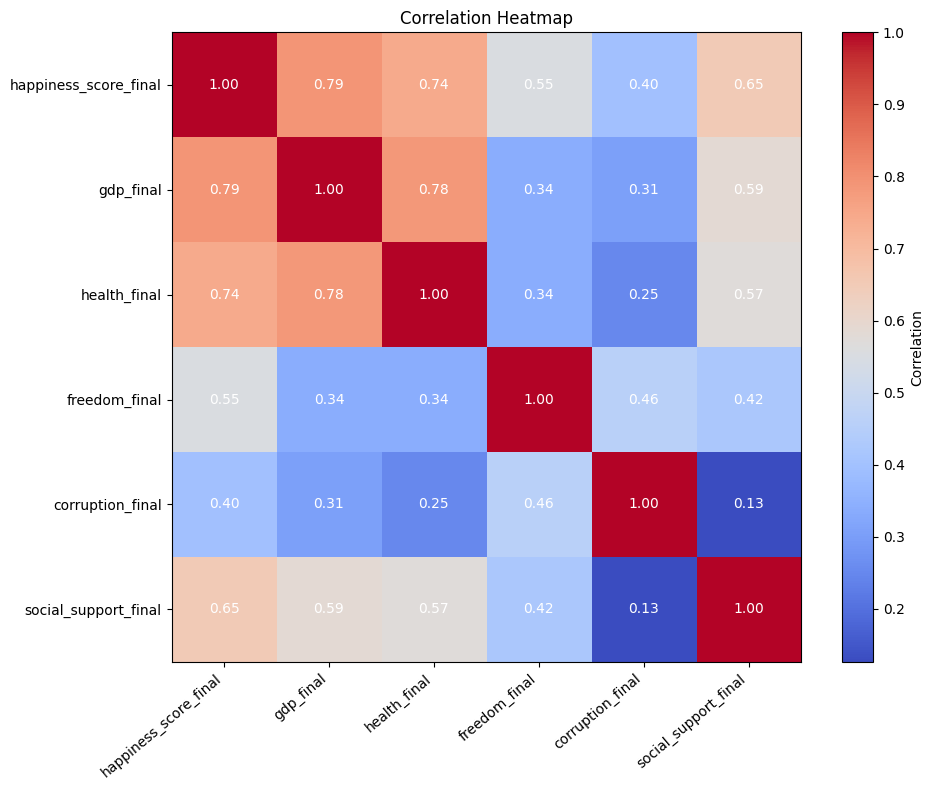

In [20]:
#Create a correlation heatmap (using imshow) between happiness score and contributing factors.
cols=['happiness_score_final','gdp_final','health_final','freedom_final','corruption_final','social_support_final']
corr_matrix = combined_df_copy[cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm',interpolation='nearest')

plt.colorbar(label='Correlation')

plt.xticks(np.arange(len(cols)), cols, rotation=40,ha='right')
plt.yticks(np.arange(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center', color='white')
plt.title('Correlation Heatmap')
plt.tight_layout()
#save plot--------------------
plt.savefig('correlation_heatmap.png',dpi=300,bbox_inches='tight')
plt.show()

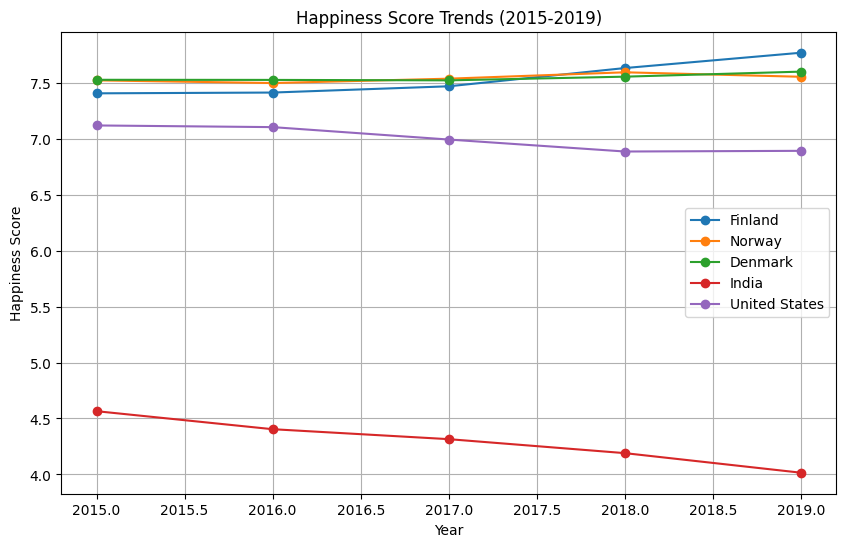

In [21]:
#. Plot the trend of happiness scores over years for 5 selected countries on a single line chart.

countries = ['Finland', 'Norway', 'Denmark', 'India', 'United States']

plt.figure(figsize=(10, 6))

for country in countries:
    country_data = combined_df_copy[
        combined_df_copy['country_final'] == country
    ]

    plt.plot(
        country_data['year'],
        country_data['happiness_score_final'],
        marker='o',
        label=country
    )

plt.title('Happiness Score Trends (2015-2019)')
plt.xlabel('Year')
plt.ylabel('Happiness Score')
plt.legend()
plt.grid(True)
#save plot--------------------
plt.savefig('line-chart.png',dpi=300,bbox_inches='tight')
plt.show()

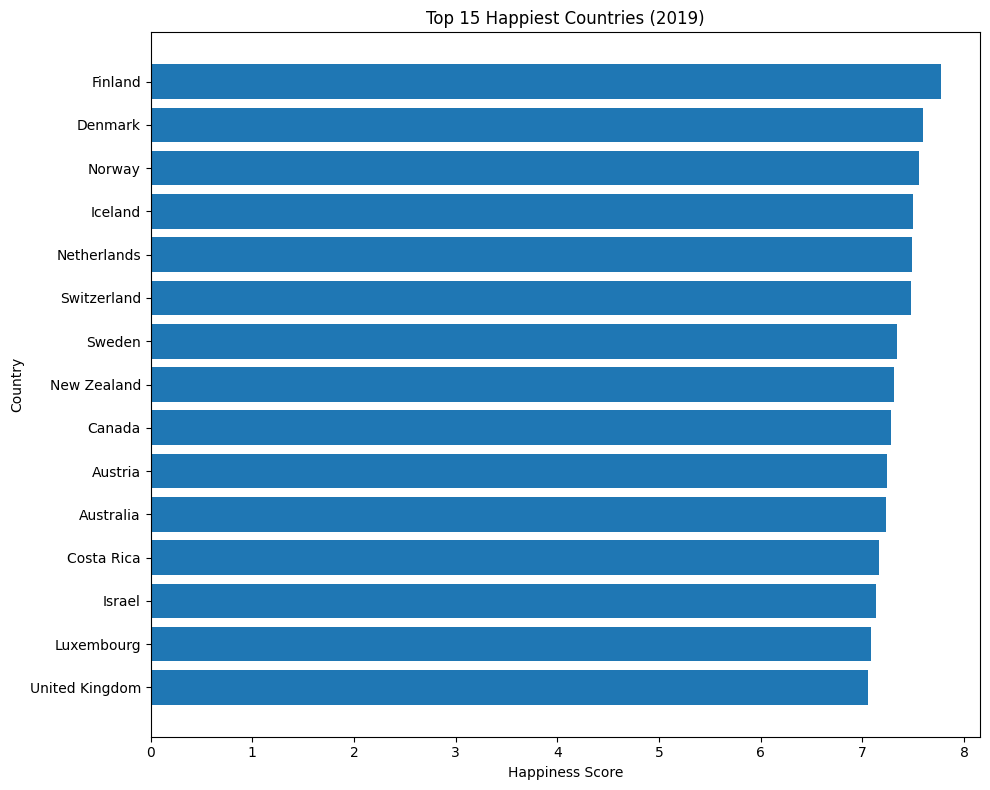

In [22]:
#Create a horizontal bar chart of the top 15 happiest countries in the most recent year.

# Filter most recent year
latest_year = combined_df_copy['year'].max()

latest_data = combined_df_copy[
    combined_df_copy['year'] == latest_year
]

# Top 15 happiest countries
top15 = (
    latest_data
    .sort_values('happiness_score_final', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top15['country_final'],
    top15['happiness_score_final']
)

plt.title(f'Top 15 Happiest Countries ({latest_year})')
plt.xlabel('Happiness Score')
plt.ylabel('Country')

# Highest score at the top
plt.gca().invert_yaxis()

plt.tight_layout()
#save plot--------------------
plt.savefig('bar-chart.png',dpi=300,bbox_inches='tight')
plt.show()

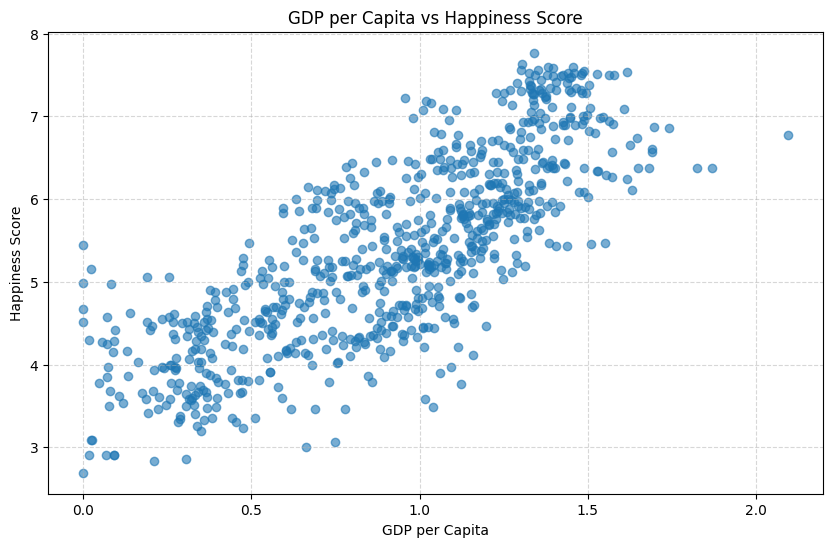

In [23]:
#Use a scatter plot to visualize the relationship between GDP per capita and happiness score.

plt.figure(figsize=(10, 6))

plt.scatter(
    combined_df_copy['gdp_final'],
    combined_df_copy['happiness_score_final'],
    alpha=0.6
)

plt.title('GDP per Capita vs Happiness Score')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')

plt.grid(True, linestyle='--', alpha=0.5)
# Save all plots as PNG files
plt.savefig("scatter-plot.png")
plt.show()

In [24]:
# export the cleaned/processed DataFrame to a new CSV.
combined_df_copy.to_csv("cleaned_processed_data.csv", index=False)

print("All plots saved as PNG files.")
print("Cleaned DataFrame exported to 'cleaned_processed_data.csv'.")

All plots saved as PNG files.
Cleaned DataFrame exported to 'cleaned_processed_data.csv'.
